# Example: Compute the Price of an American Call and Put Option Contracts using CRR
In this example, we compare the prices of American call and put contracts using the Cox-Ross-Rubinstein (CRR) binomial model with what we observe in the market for AMD options contracts.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Build binomial tree models__ for equity price evolution using the Cox-Ross-Rubinstein (CRR) model to establish the foundation for American option pricing.
> * __Compute American option premiums__ using backward induction on CRR trees by evaluating the early exercise feature and working backward from expiration to the present time.
> * __Compare theoretical and market prices__ to identify mispriced contracts by computing CRR prices and evaluating them against observed bid-ask spreads.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`
Precompiling packages...
   3714.2 ms  ✓ VLQuantitativeFinancePackage
  1 dependency successfully precompiled in 6 seconds. 528 already precompiled.
  35 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, IJulia, InteractiveUtils, JLLWrappers, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Pkg → REPLExt, PrecompileTools, Preferences, Printf, REPL, StyledStrings, TOML, Tar, UUIDs, Unicode, ZMQ, ZeroMQ_jll, Zlib_jll, libsodium_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 344 dependents of these packages may trigger further precompilation to work with the unexpected versions.


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
To start, load the options data using [the `MyOptionsChainDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyOptionsChainDataSet) and store the data in the `metadata::Dict{String,Any}` and `optionschain::DataFrame` variables.

In [2]:
metadata, optionschain = let
    
    # initialize -
    options_dataset = MyOptionsChainDataSet(ticker="amd");
    metadata = options_dataset.metadata;
    optionschain = options_dataset.data;

    (metadata, optionschain) # return
end;

What's in the metadata dictionary?

In [3]:
metadata |> keys

KeySet for a Dict{String, Any} with 10 entries. Keys:
  "DTE"
  "purchase_date"
  "historical_volatility"
  "underlying_share_price_ask"
  "source"
  "underlying_share_price_bid"
  "is_weekly"
  "atm_IV"
  "expiration_date"
  "underlying_share_price_mid"

What about the optionschain variable?

In [4]:
optionschain

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,25.0,0.8907,203.1,204.0,204.9,209.72,0,419,2.1122,0.9989,Call
2,30.0,0.8688,198.2,199.05,199.9,206.3,0,163,1.9784,0.9985,Call
3,35.0,0.847,193.2,193.98,194.75,199.75,0,17,0.0,0.0,Call
4,40.0,0.8251,188.3,189.1,189.9,176.24,0,18,1.6654,0.9985,Call
5,45.0,0.8033,183.25,184.13,185.0,174.11,0,318,1.5375,0.9985,Call
6,50.0,0.7814,178.4,179.1,179.8,167.46,0,691,1.2356,0.9996,Call
7,55.0,0.7596,173.35,174.13,174.9,177.43,0,176,1.0885,0.9998,Call
8,60.0,0.7377,168.5,169.3,170.1,162.15,0,332,1.3802,0.9967,Call
9,65.0,0.7158,163.45,164.33,165.2,175.38,0,180,1.2927,0.9967,Call


### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values.

Two of these deserve a note. The chain is a __frozen snapshot__, quoted on the `purchase_date` in the metadata, so `Sₒ` is the share price on that date and not a live price. And `h` sets the lattice resolution: with `h = 5*DTE` levels spanning `T` years, one lattice step is `Δt_lattice = T/h = 1/1825` yr regardless of `DTE`.

In [5]:
Sₒ = metadata["underlying_share_price_mid"] |> x-> parse(Float64,x); # share price on the quote date (USD/share)
DTE = metadata["DTE"] |> x-> parse(Float64,x); # days to expiration (days)
day = (1/365); # one day, expressed in years
T = (DTE)*day; # time to expiration (years)
gᵧ = 0.040; # continuously compounded risk-free rate (1/yr)
h = 5*DTE |> Int64; # number of levels of the tree, five per day
Δt_lattice = T/h; # length of one lattice step (years)
σ_min = abs(gᵧ)*sqrt(Δt_lattice); # below this volatility the lattice has no valid risk-neutral probability

In [6]:
println("Quote date: $(metadata["purchase_date"]), expiration $(metadata["expiration_date"]), DTE = $(DTE) days");
println("Sₒ = $(Sₒ) USD/share, T = $(round(T, digits=4)) yr, h = $(h) levels, Δt_lattice = $(round(Δt_lattice, sigdigits=4)) yr");
println("no-arbitrage volatility floor σ_min = |gᵧ|*sqrt(Δt_lattice) = $(round(σ_min, sigdigits=4))");

Quote date: 2025-10-22, expiration 2025-12-19, DTE = 58.0 days
Sₒ = 225.78 USD/share, T = 0.1589 yr, h = 290 levels, Δt_lattice = 0.0005479 yr
no-arbitrage volatility floor σ_min = |gᵧ|*sqrt(Δt_lattice) = 0.0009363


___

## Task 1: Compute the Price of American Call Contracts
In this task, we'll compute the price of American call contracts using the CRR binomial model written against [Advanced Micro Devices, Inc. (AMD)](https://finance.yahoo.com/quote/AMD/).

Let's start by filtering the options chain data for call contracts, then we'll compute the price of each contract using the CRR binomial model. We'll use [the `filter(...)` function](https://dataframes.juliadata.org/stable/lib/functions/#Base.filter) to filter out the call contracts from the `optionschain` DataFrame.

In [7]:
call_contract_data = filter(row -> row[:Type] == "Call", optionschain)

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,25.0,0.8907,203.1,204.0,204.9,209.72,0,419,2.1122,0.9989,Call
2,30.0,0.8688,198.2,199.05,199.9,206.3,0,163,1.9784,0.9985,Call
3,35.0,0.847,193.2,193.98,194.75,199.75,0,17,0.0,0.0,Call
4,40.0,0.8251,188.3,189.1,189.9,176.24,0,18,1.6654,0.9985,Call
5,45.0,0.8033,183.25,184.13,185.0,174.11,0,318,1.5375,0.9985,Call
6,50.0,0.7814,178.4,179.1,179.8,167.46,0,691,1.2356,0.9996,Call
7,55.0,0.7596,173.35,174.13,174.9,177.43,0,176,1.0885,0.9998,Call
8,60.0,0.7377,168.5,169.3,170.1,162.15,0,332,1.3802,0.9967,Call
9,65.0,0.7158,163.45,164.33,165.2,175.38,0,180,1.2927,0.9967,Call


Next, we'll process each contract in the `call_contract_data::DataFrame` collection to compute its price using the CRR binomial model. We'll use a loop to iterate through each row of the DataFrame and apply the CRR pricing function to each contract's specific parameters (strike price, time to expiration, implied volatility, etc.).

We'll save the strike price, the observed price, and the computed price for each contract in the `call_contract_price_df::DataFrame` for later analysis.

__Strategy:__
For each contract in `call_contract_data::DataFrame,` get the `strike,` `IV,` `Bid,` and `Ask` values, and use these parameters (along with the current share price) to construct [an `MyAdjacencyBasedCRREquityPriceTree`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.MyAdjacencyBasedCRREquityPriceTree) and [`MyAmericanCallContractModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.MyAmericanCallContractModel) instances. 
* Use [the `premium(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.premium) to compute the premium (price) of each option contract.
* Price the __same contract twice on the same tree__: once with the default American rule, and once with a continuation-only choice function, which is the European recursion of the lecture. The difference between them is the early-exercise premium.
* Populate records in the `call_contract_price_df::DataFrame,` capturing the strike `K,` `bid,` `ask,` both computed premiums, and a `wide::Bool` field. The `wide::Bool` field holds a `true|false` value indicating whether the American premium $\mathcal{P}$ lies outside the widened quote interval $\left(1-\delta\right)\cdot\text{Bid}\leq\mathcal{P}\leq\left(1+\delta\right)\cdot\text{Ask}$, with $\delta=0.15$.

> __Why $\delta$ is 15% and not something tight.__ The band is deliberately loose. Quotes and the underlying price are not simultaneous, the package rounds the lattice premium to four significant digits, and the model's only volatility input is the vendor's own implied volatility for that contract. A tight band would flag almost every row and would be measuring those frictions, not disagreement about value.

One more input needs a decision before the loop can run.

> __Missing volatility.__ Some rows carry `IV = 0`, which is the vendor's placeholder for "not published", not a real volatility. The lecture says never to force an invalid input through the model, so we __skip__ those contracts and report how many were skipped rather than substituting a small number for them. We also check each tree's risk-neutral probability lies in $(0,1)$ before trusting its premium.

So what do we get?

In [8]:
call_contract_price_df, skipped_calls = let

    # initialize -
    data = call_contract_data;
    number_of_contracts = nrow(data);
    call_contract_price_df = DataFrame();
    θ = 1; # for premium calculations, we *always* set this to a long position
    δ = 0.15; # width of the widened quote interval
    european_choice = (intrinsic, continuation) -> continuation; # the European recursion
    skipped = Float64[];

    for i ∈ 1:number_of_contracts
        
        # get data from the contract -
        K = data[i,:Strike]; # strike price
        mid = data[i,:Mid];
        bid = data[i,:Bid];
        ask = data[i,:Ask];
        IV = data[i,:IV]; # implied volatility

        # the vendor writes 0 for a missing IV: skip, do not impute -
        if (IV ≤ σ_min)
            push!(skipped, K);
            continue;
        end

        # build the model -
        contract_model = build(MyAmericanCallContractModel, (
            K = K, premium = 0.0, sense = θ, copy = 1
        ));

        # build the tree for a contract i. Note the two step process: first we build an (empty) tree structure, then we populate it with future share price data
        tree_model = build(MyAdjacencyBasedCRREquityPriceTree, 
            (μ = gᵧ, T = T, σ = IV)) |> (x-> populate(x, Sₒ = Sₒ, h = h));

        # the lattice is only a pricing model where its risk-neutral probability is a probability -
        # the package keyword and field are named p; it holds the q of the lecture
        @assert 0.0 < tree_model.p < 1.0

        # price the same contract twice on the same tree: American rule, then European rule.
        # premium(...) rounds to four significant digits by default, so we also take an
        # unrounded pair to check that any American-European gap is real and not rounding.
        𝒫_american = premium(contract_model, tree_model);
        𝒫_european = premium(contract_model, tree_model; choice = european_choice);
        raw_gap = premium(contract_model, tree_model; sigdigits = 15) -
                  premium(contract_model, tree_model; choice = european_choice, sigdigits = 15);

        # populate the data frame -
        row = (
            K = K,
            IV = IV,
            mid = mid,
            bid = bid,
            ask = ask,
            american = 𝒫_american,
            european = 𝒫_european,
            raw_gap = raw_gap,
            wide = !(((1-δ)*bid <= 𝒫_american) && (𝒫_american <= (1+δ)*ask))
        );
        push!(call_contract_price_df, row);
    end

    call_contract_price_df, skipped # return
end;

So what do we see? Let's also report how many contracts were skipped for missing volatility, and check the lecture's theorem: for a non-dividend-paying underlying with $g_y\geq0$, early exercise of a call is never strictly better, so the American and European call premiums should agree.

The `raw_gap` column repeats that comparison without the four-significant-digit rounding, so a zero there means the two recursions returned the identical floating-point number at every node, not merely numbers that round alike.

In [9]:
println("priced $(nrow(call_contract_price_df)) call contracts; skipped $(length(skipped_calls)) with missing IV at strikes $(skipped_calls)");
println("max |American - European| across the call chain = $(maximum(abs.(call_contract_price_df.american .- call_contract_price_df.european))) USD/share (rounded)");
println("max |American - European| unrounded                = $(maximum(abs.(call_contract_price_df.raw_gap))) USD/share");
println("contracts outside the widened quote interval: $(count(call_contract_price_df.wide))");
call_contract_price_df

priced 63 call contracts; skipped 1 with missing IV at strikes [35.0]
max |American - European| across the call chain = 0.0 USD/share (rounded)
max |American - European| unrounded                = 0.0 USD/share
contracts outside the widened quote interval: 1


Row,K,IV,mid,bid,ask,american,european,raw_gap,wide
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Bool
1,25.0,2.1122,204.0,203.1,204.9,201.0,201.0,0.0,false
2,30.0,1.9784,199.05,198.2,199.9,196.1,196.1,0.0,false
3,40.0,1.6654,189.1,188.3,189.9,186.1,186.1,0.0,false
4,45.0,1.5375,184.13,183.25,185.0,181.1,181.1,0.0,false
5,50.0,1.2356,179.1,178.4,179.8,176.1,176.1,0.0,false
6,55.0,1.0885,174.13,173.35,174.9,171.1,171.1,0.0,false
7,60.0,1.3802,169.3,168.5,170.1,166.3,166.3,0.0,false
8,65.0,1.2927,164.33,163.45,165.2,161.3,161.3,0.0,false
9,70.0,1.5074,159.3,158.55,160.05,156.9,156.9,0.0,false


### Visualize
Let's plot the computed prices against the quoted mid prices across strike, marking the contracts whose model value falls outside the widened quote interval.

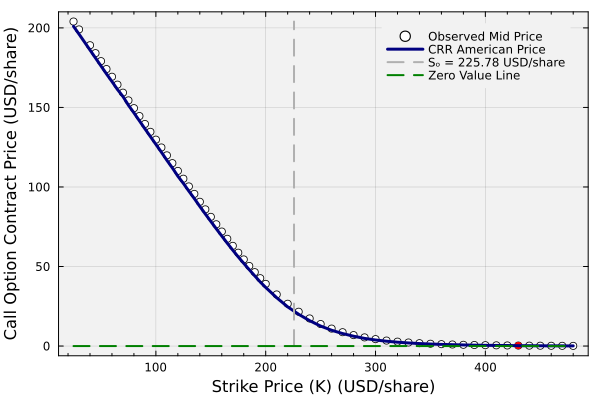

In [10]:
let
    # initialize -
    data = call_contract_price_df;
    number_of_contracts = nrow(data);
    number_of_steps = 100;
    fig = plot();

    # plot the observed mid prices -
    scatter!(
        data[:,:K], data[:,:mid],
        label="Observed Mid Price", color=:white, ms=4, markershape=:circle
    );

    for i ∈ 1:number_of_contracts
        
        wide_flag = data[i,:wide];
        if (wide_flag == true)
            scatter!(
                [data[i,:K]], [data[i,:mid]],
                markershape=:circle, msc=:red, c=:red,label="", ms=4,
            );
        end
    end

    plot!(
        data[:,:K], data[:,:american],
        label="CRR American Price", color=:navy, lw=3, xminorticks=true
    )

    # current share price line -
    VLINE = zeros(number_of_steps, 2)
    VLINE[:,1] .= Sₒ*ones(number_of_steps)
    VLINE[:,2] .= range(0, stop = maximum(data[:,:mid]), length = number_of_steps) |> collect;
    plot!(VLINE[:,1], VLINE[:,2], lw=2, c= :gray69, ls=:dash, label="Sₒ = $(Sₒ) USD/share")

    # zero value line -
    BEL = zeros(number_of_contracts);
    plot!(data[:,:K], BEL, lw=2, c=:green, ls=:dash, label="Zero Value Line")
    
    xlabel!("Strike Price (K) (USD/share)");
    ylabel!("Call Option Contract Price (USD/share)");

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);  

end

### Discussion
* Why does the premium of a __call option__ contract increase as $K\rightarrow{0}$ for $S_{0}$ = 225.78 USD/share? For example, what could you do if you purchased a call with a strike of $K=140$ USD/share?
* The American and European call premiums came out identical to the resolution of this lattice. Which assumption of the lecture's theorem is doing the work, and what would have to change about AMD for the two columns to separate?
___

## Task 2: Compute the Price of American Put Contracts
In this task, we'll compute the price of American put contracts using the CRR binomial model written against [Advanced Micro Devices, Inc. (AMD)](https://finance.yahoo.com/quote/AMD/). We will follow a similar approach as in Task 1, but this time focusing on put contracts.

Let's start by filtering the options chain data for put contracts, then we'll compute the price of each contract using the CRR binomial model. We'll use [the `filter(...)` function](https://dataframes.juliadata.org/stable/lib/functions/#Base.filter) to filter out the put contracts from the `optionschain` DataFrame.

In [11]:
put_contract_data = filter(row -> row[:Type] == "Put", optionschain)

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,25.0,-0.8907,0.0,0.02,0.03,0.02,0,"3,137",1.9233,-0.0005,Put
2,30.0,-0.8688,0.0,0.01,0.01,0.02,0,741,1.6054,-0.0002,Put
3,35.0,-0.847,0.0,0.01,0.01,0.02,0,252,1.4834,-0.0003,Put
4,40.0,-0.8251,0.0,0.02,0.04,0.01,0,"2,119",1.5545,-0.0009,Put
5,45.0,-0.8033,0.01,0.03,0.04,0.01,2,"1,031",1.2863,-0.0003,Put
6,50.0,-0.7814,0.01,0.03,0.05,0.01,244,"1,033",1.2042,-0.0003,Put
7,55.0,-0.7596,0.02,0.04,0.06,0.06,10,"1,173",1.3273,-0.0015,Put
8,60.0,-0.7377,0.03,0.05,0.07,0.04,58,"3,006",1.1994,-0.0011,Put
9,65.0,-0.7158,0.05,0.06,0.07,0.06,0,"2,959",1.1765,-0.0017,Put


Next, we'll process each contract in the `put_contract_data::DataFrame` collection to compute its price using the CRR binomial model. We'll use the same strategy as in Task 1, including skipping contracts with a missing implied volatility, but this time for put contracts.

Puts are where the exercise style earns its keep. The lecture says an American put can be worth strictly more than the otherwise identical European put, so we keep both columns and look at the difference.

In [12]:
put_contract_price_df, skipped_puts = let

    # initialize -
    data = put_contract_data;
    number_of_contracts = nrow(data);
    put_contract_price_df = DataFrame();
    θ = 1; # for premium calculations, we *always* set this to a long position
    δ = 0.15; # width of the widened quote interval
    european_choice = (intrinsic, continuation) -> continuation; # the European recursion
    skipped = Float64[];

    for i ∈ 1:number_of_contracts
        
        # get data from the contract -
        K = data[i,:Strike]; # strike price
        mid = data[i,:Mid];
        bid = data[i,:Bid];
        ask = data[i,:Ask];
        IV = data[i,:IV]; # implied volatility

        # the vendor writes 0 for a missing IV: skip, do not impute -
        if (IV ≤ σ_min)
            push!(skipped, K);
            continue;
        end

        # build the model - use the put contract model
        contract_model = build(MyAmericanPutContractModel, (
            K = K, premium = 0.0, sense = θ, copy = 1
        ));

        # build the tree for a contract i. Note the two step process: first we build an (empty) tree structure, then we populate it with future share price data
        tree_model = build(MyAdjacencyBasedCRREquityPriceTree, 
            (μ = gᵧ, T = T, σ = IV)) |> (x-> populate(x, Sₒ = Sₒ, h = h));

        # the package keyword and field are named p; it holds the q of the lecture
        @assert 0.0 < tree_model.p < 1.0

        # price the same contract twice on the same tree: American rule, then European rule
        𝒫_american = premium(contract_model, tree_model);
        𝒫_european = premium(contract_model, tree_model; choice = european_choice);

        # populate the data frame -
        row = (
            K = K,
            IV = IV,
            mid = mid,
            bid = bid,
            ask = ask,
            american = 𝒫_american,
            european = 𝒫_european,
            early_ex = 𝒫_american - 𝒫_european,
            wide = !(((1-δ)*bid <= 𝒫_american) && (𝒫_american <= (1+δ)*ask))
        );
        push!(put_contract_price_df, row);
    end

    put_contract_price_df, skipped # return
end;

So what do we see? The `early_ex` column is the early-exercise premium contract by contract.

In [13]:
println("priced $(nrow(put_contract_price_df)) put contracts; skipped $(length(skipped_puts)) with missing IV at strikes $(skipped_puts)");
println("puts with a strictly positive early-exercise premium: $(count(>(0.0), put_contract_price_df.early_ex)) of $(nrow(put_contract_price_df))");
println("puts with a negative early-exercise premium (should be none): $(count(<(0.0), put_contract_price_df.early_ex))");
println("largest early-exercise premium = $(maximum(put_contract_price_df.early_ex)) USD/share, at K = $(put_contract_price_df.K[argmax(put_contract_price_df.early_ex)])");
println("contracts outside the widened quote interval: $(count(put_contract_price_df.wide))");
put_contract_price_df

priced 64 put contracts; skipped 0 with missing IV at strikes Float64[]
puts with a strictly positive early-exercise premium: 63 of 64
puts with a negative early-exercise premium (should be none): 0
largest early-exercise premium = 2.3000000000000114 USD/share, at K = 480.0
contracts outside the widened quote interval: 0


Row,K,IV,mid,bid,ask,american,european,early_ex,wide
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Bool
1,25.0,1.9233,0.02,0.0,0.03,0.0309,0.03088,2.0e-5,false
2,30.0,1.6054,0.01,0.0,0.01,0.01026,0.01026,0.0,false
3,35.0,1.4834,0.01,0.0,0.01,0.01034,0.01033,1.0e-5,false
4,40.0,1.5545,0.02,0.0,0.04,0.04164,0.04161,3.0e-5,false
5,45.0,1.2863,0.03,0.01,0.04,0.01051,0.0105,1.0e-5,false
6,50.0,1.2042,0.03,0.01,0.05,0.01059,0.01058,1.0e-5,false
7,55.0,1.3273,0.04,0.02,0.06,0.06347,0.06341,6.0e-5,false
8,60.0,1.1994,0.05,0.03,0.07,0.04275,0.0427,5.0e-5,false
9,65.0,1.1765,0.06,0.05,0.07,0.06429,0.06423,6.0e-5,false


### Visualize
Let's plot the computed prices against the quoted mid prices across strike, marking the contracts whose model value falls outside the widened quote interval.

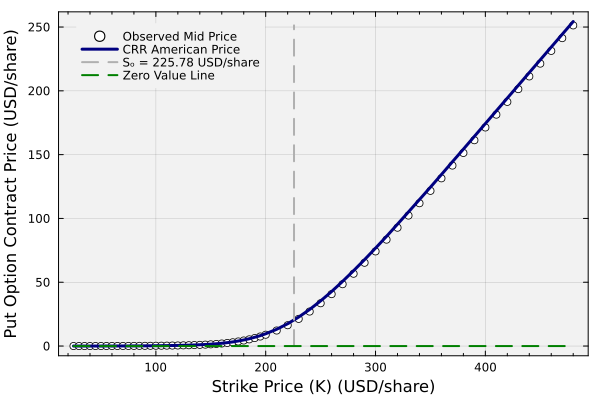

In [14]:
let
    # initialize -
    data = put_contract_price_df;
    number_of_contracts = nrow(data);
    number_of_steps = 100;
    fig = plot();

    # plot the observed mid prices -
    scatter!(
        data[:,:K], data[:,:mid],
        label="Observed Mid Price", color=:white, ms=4, markershape=:circle
    );

    for i ∈ 1:number_of_contracts
        
        wide_flag = data[i,:wide];
        if (wide_flag == true)
            scatter!(
                [data[i,:K]], [data[i,:mid]],
                markershape=:circle, msc=:red, c=:red,label="", ms=4,
            );
        end
    end

    plot!(
        data[:,:K], data[:,:american],
        label="CRR American Price", color=:navy, lw=3, xminorticks=true
    )

    # current share price line -
    VLINE = zeros(number_of_steps, 2)
    VLINE[:,1] .= Sₒ*ones(number_of_steps)
    VLINE[:,2] .= range(0, stop = maximum(data[:,:mid]), length = number_of_steps) |> collect;
    plot!(VLINE[:,1], VLINE[:,2], lw=2, c= :gray69, ls=:dash, label="Sₒ = $(Sₒ) USD/share")

    # zero value line -
    BEL = zeros(number_of_contracts);
    plot!(data[:,:K], BEL, lw=2, c=:green, ls=:dash, label="Zero Value Line")
    
    xlabel!("Strike Price (K) (USD/share)");
    ylabel!("Put Option Contract Price (USD/share)");

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);  

end

### Discussion
* Why does the premium of a __put option contract__ increase as $K\rightarrow{\infty}$ for $S_{0}$ = 225.78 USD/share? For example, what could you do if you purchased a put with a strike of $K=400$ USD/share?
* Where in the strike range is the early-exercise premium largest, and does that match what the lecture predicts about which puts are worth exercising early?
___

## Summary
This example priced an entire AMD option chain on CRR lattices, ran the American and European recursions on the same trees, and compared both against quoted bid-ask intervals.

> __Key Takeaways:__
>
> * __Backward induction computes American premiums:__ Each contract is priced by working backward from expiration through the tree, evaluating at each node whether immediate exercise beats the discounted expected continuation value. Switching the choice function to continuation-only turns the same tree into a European pricer.
> * __The call theorem holds numerically:__ For this non-dividend-paying underlying at a positive rate, the American and European call premiums agree across the whole chain, while nearly every put carries a positive early-exercise premium, reaching about 2.30 USD/share at the deepest in-the-money strike. It is not monotone in strike, because each contract is priced at its own implied volatility and the premiums are rounded to four significant digits.
> * __Model-versus-quote gaps are diagnostics, not opportunities:__ Each contract is priced with its own quoted implied volatility, so the model is being fed the market's answer; the remaining gap reflects rounding, non-simultaneous quotes, and the exercise convention rather than a tradable mispricing.

Comparing a lattice price with a quoted interval is a reconciliation exercise. Before calling any gap an opportunity, the timestamp, dividend assumptions, rate, volatility source, and transaction costs all have to line up.
___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___